# SWATCH 방호성능 - 다변량 선형회귀 (OLS)

| M | Y 변환 | X 변환 | 파라미터 수 |
|---|---|---|---|
| M1 | 없음 | 없음 | 2 |
| M2 | 없음 | log | 2 |
| M3 | log | 없음 | 2 |
| M4 | log | log (power-law) | 2 |
| M5 | log | log + 교호작용 | 3 |
| M6 | log | log + 2차항 | 4 |

> 주의: n=9, 자유도 3-6 수준 -> p-값 해석 주의

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, r2_score
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

---
## 0. 데이터 로드 및 변환 변수 생성

In [2]:
raw = pd.read_excel('./datasets/swatch.xlsx')
df = pd.DataFrame()
df['Sample'] = raw.iloc[:, 0]
df['x1']     = raw.iloc[:, 1]   # 평량(g/m2)
df['x2']     = raw.iloc[:, 2]   # BET(m2/g)
df['y_GD']   = raw.iloc[:, 3]   # SWATCH(GD) 24h(Con)
df['y_HD']   = raw.iloc[:, 4]   # SWATCH(HD) 24h(Con)
df['lx1']    = np.log(df['x1'])
df['lx2']    = np.log(df['x2'])
df['ly_GD']  = np.log(df['y_GD'])
df['ly_HD']  = np.log(df['y_HD'])
print(f'샘플 수: {len(df)}')
df

샘플 수: 9


,Sample,x1,x2,y_GD,y_HD,lx1,lx2,ly_GD,ly_HD
0,ACF25-01,105.20,1150,320,280,4.655863,7.047517,5.768321,5.634790
1,ACF25-02,99.30,1450,470,220,4.598146,7.279319,6.152733,5.393628
2,ACF25-03,119.70,1150,1150,550,4.784989,7.047517,7.047517,6.309918
3,ACF25-04,110.40,1300,850,850,4.704110,7.170120,6.745236,6.745236
4,ACF25-05,103.44,1016,470,580,4.638992,6.923629,6.152733,6.363028
5,ACF25-06,122.83,1080,20,140,4.810801,6.984716,2.995732,4.941642
6,ACF25-07,154.49,1139,380,10,5.040129,7.037906,5.940171,2.302585
7,ACF25-08,140.00,1300,20,5,4.941642,7.170120,2.995732,1.609438
8,ACF25-09,130.00,2197,50,5,4.867534,7.694848,3.912023,1.609438


---
## 1. EDA - 산점도

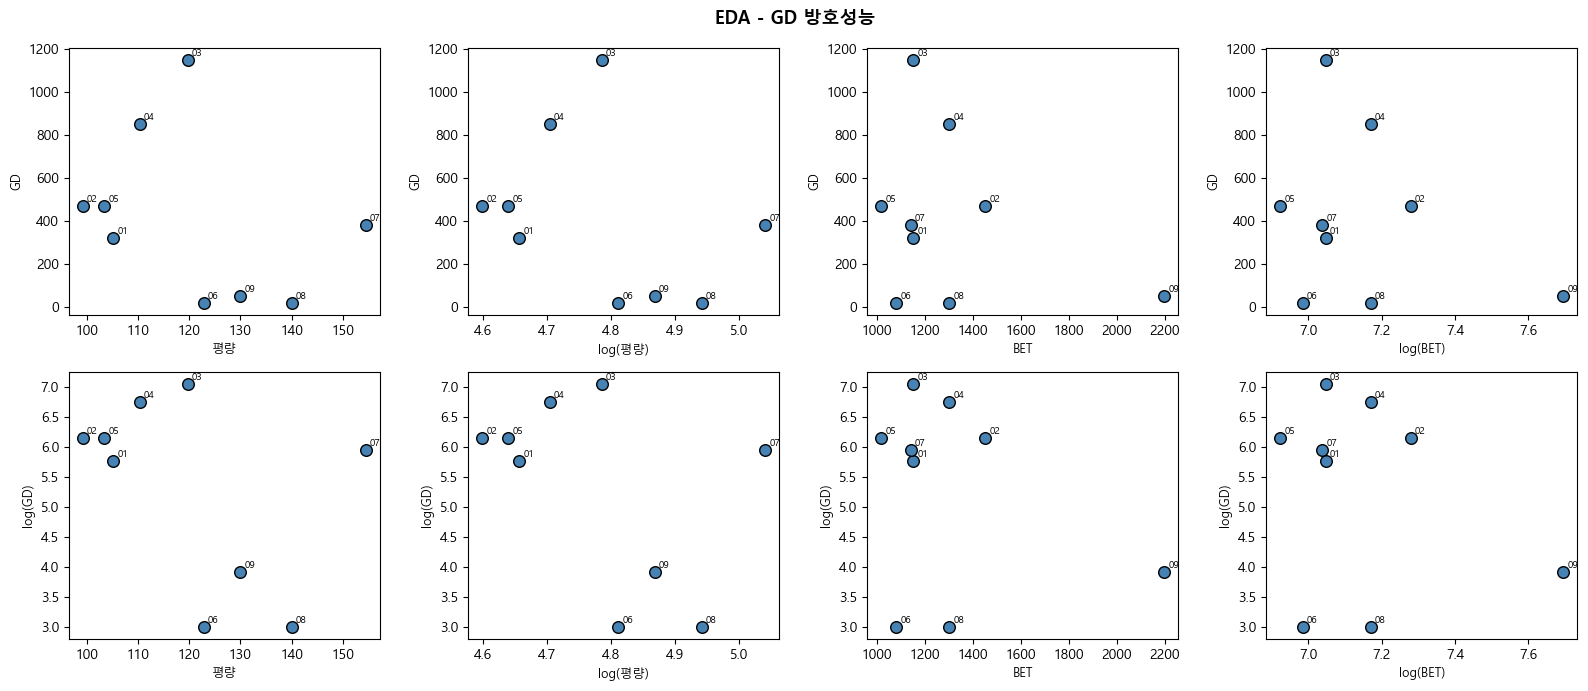

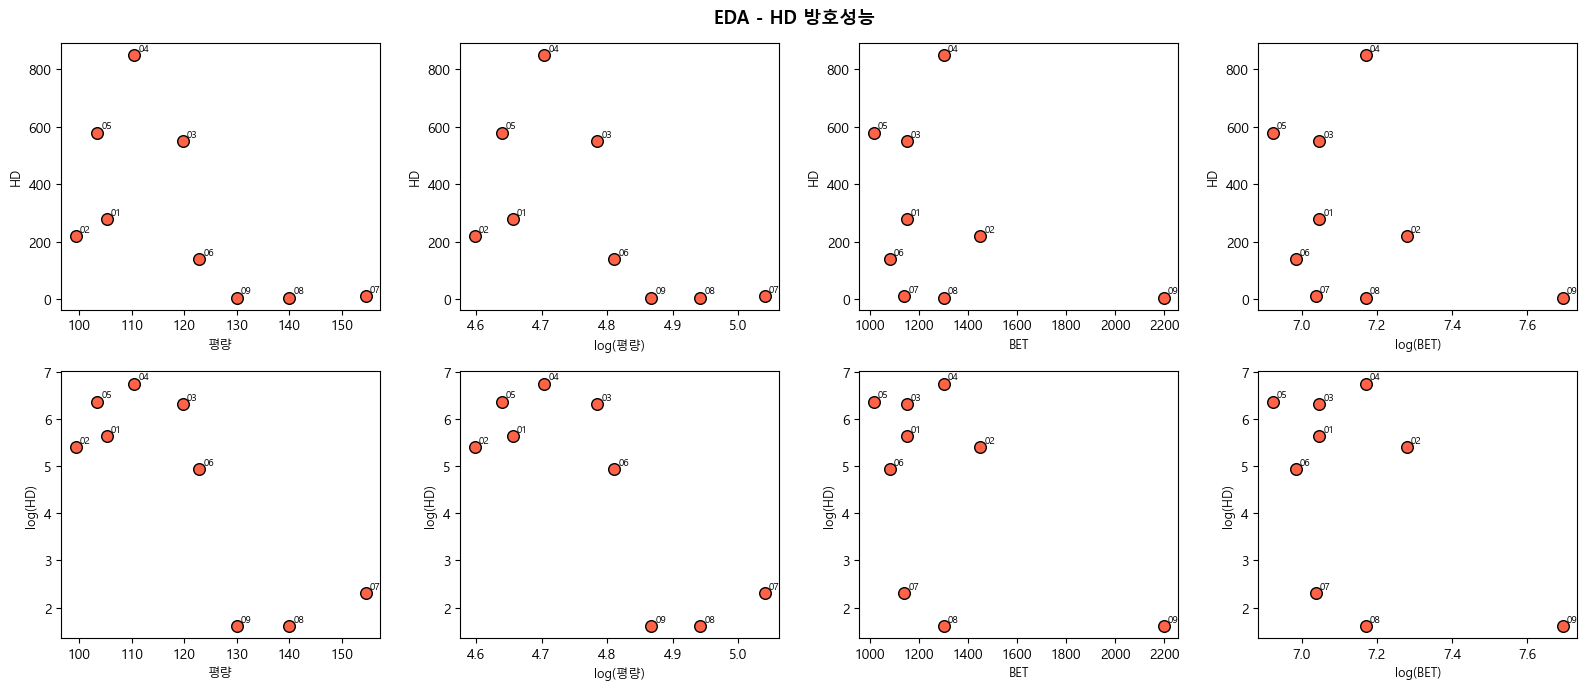

In [3]:
xp = [('x1','평량'),('lx1','log(평량)'),('x2','BET'),('lx2','log(BET)')]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ci,(xc,xl) in enumerate(xp):
    for ri,(yc,yl) in enumerate([('y_GD','GD'),('ly_GD','log(GD)')]):
        ax = axes[ri,ci]
        ax.scatter(df[xc],df[yc],color='steelblue',edgecolors='k',s=70)
        for _,row in df.iterrows():
            ax.annotate(row['Sample'][-2:],(row[xc],row[yc]),fontsize=7,xytext=(3,3),textcoords='offset points')
        ax.set_xlabel(xl,fontsize=9); ax.set_ylabel(yl,fontsize=9)
fig.suptitle('EDA - GD 방호성능',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 7))
for ci,(xc,xl) in enumerate(xp):
    for ri,(yc,yl) in enumerate([('y_HD','HD'),('ly_HD','log(HD)')]):
        ax = axes2[ri,ci]
        ax.scatter(df[xc],df[yc],color='tomato',edgecolors='k',s=70)
        for _,row in df.iterrows():
            ax.annotate(row['Sample'][-2:],(row[xc],row[yc]),fontsize=7,xytext=(3,3),textcoords='offset points')
        ax.set_xlabel(xl,fontsize=9); ax.set_ylabel(yl,fontsize=9)
fig2.suptitle('EDA - HD 방호성능',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()

---
## 2. 헬퍼 함수

In [4]:
def run_ols_compare(df, formulas, y_raw_col):
    rows, results = [], {}
    for label, formula, is_log_y in formulas:
        res    = smf.ols(formula, data=df).fit()
        y_fit  = np.exp(res.fittedvalues) if is_log_y else res.fittedvalues
        y_true = df[y_raw_col]
        pvals  = res.pvalues.drop('Intercept', errors='ignore')
        rows.append({'model': label, 'n_params': int(res.df_model),
                     'df_resid': int(res.df_resid),
                     'R2': round(res.rsquared,4), 'adj_R2': round(res.rsquared_adj,4),
                     'AIC': round(res.aic,2), 'BIC': round(res.bic,2),
                     'F_pval': round(res.f_pvalue,4),
                     'min_coef_p': round(pvals.min(),4),
                     'RMSE': round(np.sqrt(mean_squared_error(y_true,y_fit)),2)})
        results[label] = (res, is_log_y)
    return pd.DataFrame(rows).sort_values('AIC').reset_index(drop=True), results


def plot_fitted_vs_actual(res, is_log_y, y_true, title, color='steelblue'):
    y_fit = np.exp(res.fittedvalues) if is_log_y else res.fittedvalues
    r2 = r2_score(y_true, y_fit)
    rmse = np.sqrt(mean_squared_error(y_true, y_fit))
    fig, ax = plt.subplots(figsize=(5,5))
    ax.scatter(y_true, y_fit, color=color, edgecolors='k', s=80, zorder=3)
    for i,(xt,xf) in enumerate(zip(y_true,y_fit)):
        ax.annotate(df['Sample'].iloc[i][-2:],(xt,xf),fontsize=8,xytext=(4,4),textcoords='offset points')
    lo=min(y_true.min(),y_fit.min())*0.9; hi=max(y_true.max(),y_fit.max())*1.05
    ax.plot([lo,hi],[lo,hi],'r--',lw=1.5)
    ax.set_xlim(lo,hi); ax.set_ylim(lo,hi)
    ax.set_xlabel('Actual',fontsize=11); ax.set_ylabel('Fitted',fontsize=11)
    ax.set_title(title + '  R2=' + str(round(r2,4)) + '  RMSE=' + str(round(rmse,1)), fontsize=10)
    plt.tight_layout(); plt.show()


def plot_residual_diagnostics(res, title):
    resid=res.resid; fitted=res.fittedvalues
    fig=plt.figure(figsize=(14,4)); gs=gridspec.GridSpec(1,3,figure=fig)
    ax1=fig.add_subplot(gs[0])
    ax1.scatter(fitted,resid,color='steelblue',edgecolors='k',s=60)
    ax1.axhline(0,color='r',linestyle='--',lw=1.2)
    ax1.set_xlabel('Fitted'); ax1.set_ylabel('Residuals'); ax1.set_title('Residuals vs Fitted')
    ax2=fig.add_subplot(gs[1])
    stats.probplot(resid,dist='norm',plot=ax2); ax2.set_title('Normal Q-Q')
    ax3=fig.add_subplot(gs[2])
    ax3.scatter(fitted,np.sqrt(np.abs(resid)),color='tomato',edgecolors='k',s=60)
    ax3.set_xlabel('Fitted'); ax3.set_ylabel('sqrt|Residuals|'); ax3.set_title('Scale-Location')
    fig.suptitle('잔차 진단 - ' + title, fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 3. 변환 조합별 OLS 비교

### 3-1. GD 방호성능

In [5]:
formulas_GD = [
    ('M1 raw~x1+x2',         'y_GD  ~ x1 + x2',                            False),
    ('M2 raw~log(x)',         'y_GD  ~ lx1 + lx2',                          False),
    ('M3 log(y)~x',           'ly_GD ~ x1 + x2',                             True),
    ('M4 log(y)~log(x)',      'ly_GD ~ lx1 + lx2',                           True),
    ('M5 log(y)~log(x)+intr', 'ly_GD ~ lx1 + lx2 + lx1:lx2',                True),
    ('M6 log(y)~log(x)+quad', 'ly_GD ~ lx1 + lx2 + I(lx1**2) + I(lx2**2)', True),
]
table_GD, results_GD = run_ols_compare(df, formulas_GD, 'y_GD')
print('GD 방호성능 - 변환 조합 비교 (AIC 오름차순)')
display(table_GD)

GD 방호성능 - 변환 조합 비교 (AIC 오름차순)


,model,n_params,df_resid,R2,adj_R2,AIC,BIC,F_pval,min_coef_p,RMSE
0,M4 log(y)~log(x),2,6,0.2430,-0.0093,36.12,36.71,0.4338,0.2874,385.27
1,M3 log(y)~x,2,6,0.2328,-0.0230,36.24,36.83,0.4516,0.3188,380.95
2,M5 log(y)~log(x)+intr,3,5,0.3008,-0.1187,37.40,38.19,0.5830,0.5485,389.70
3,M6 log(y)~log(x)+quad,4,4,0.3411,-0.3178,38.87,39.86,0.7304,0.5275,421.82
4,M1 raw~x1+x2,2,6,0.1818,-0.0910,135.87,136.47,0.5478,0.4520,329.06
5,M2 raw~log(x),2,6,0.1676,-0.1099,136.03,136.62,0.5768,0.4537,331.90


In [6]:
best_label_GD = table_GD.iloc[0]['model']
best_res_GD, best_log_GD = results_GD[best_label_GD]
print('=== GD 최적 모형: ' + best_label_GD + ' ===')
print(best_res_GD.summary())

=== GD 최적 모형: M4 log(y)~log(x) ===
                            OLS Regression Results                            
Dep. Variable:                  ly_GD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                    0.9630
Date:                Thu, 30 Apr 2026   Prob (F-statistic):              0.434
Time:                        11:37:04   Log-Likelihood:                -15.059
No. Observations:                   9   AIC:                             36.12
Df Residuals:                       6   BIC:                             36.71
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     36.

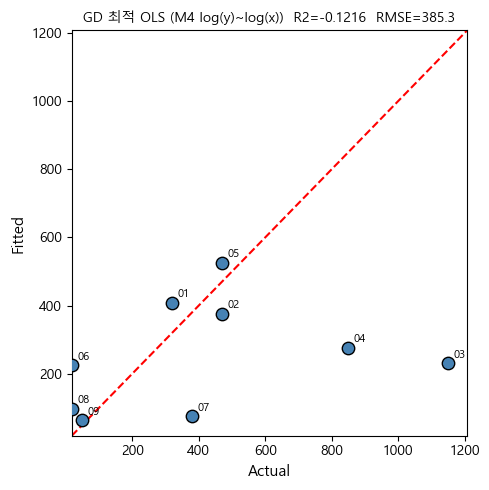

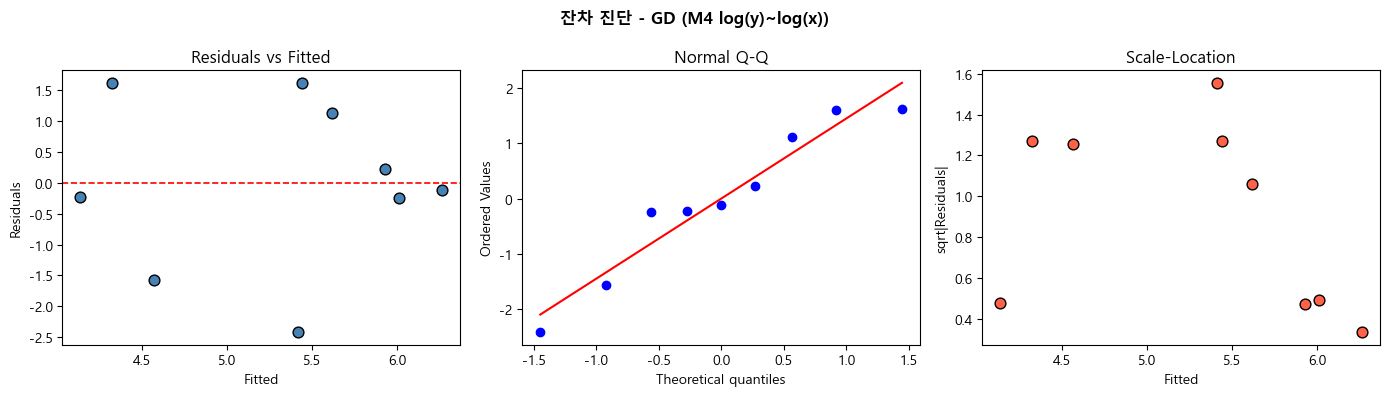

In [7]:
plot_fitted_vs_actual(best_res_GD, best_log_GD, df['y_GD'],
                      'GD 최적 OLS (' + best_label_GD + ')', color='steelblue')
plot_residual_diagnostics(best_res_GD, 'GD (' + best_label_GD + ')')

### 3-2. HD 방호성능

In [8]:
formulas_HD = [
    ('M1 raw~x1+x2',         'y_HD  ~ x1 + x2',                            False),
    ('M2 raw~log(x)',         'y_HD  ~ lx1 + lx2',                          False),
    ('M3 log(y)~x',           'ly_HD ~ x1 + x2',                             True),
    ('M4 log(y)~log(x)',      'ly_HD ~ lx1 + lx2',                           True),
    ('M5 log(y)~log(x)+intr', 'ly_HD ~ lx1 + lx2 + lx1:lx2',                True),
    ('M6 log(y)~log(x)+quad', 'ly_HD ~ lx1 + lx2 + I(lx1**2) + I(lx2**2)', True),
]
table_HD, results_HD = run_ols_compare(df, formulas_HD, 'y_HD')
print('HD 방호성능 - 변환 조합 비교 (AIC 오름차순)')
display(table_HD)

HD 방호성능 - 변환 조합 비교 (AIC 오름차순)


,model,n_params,df_resid,R2,adj_R2,AIC,BIC,F_pval,min_coef_p,RMSE
0,M3 log(y)~x,2,6,0.8304,0.7738,27.95,28.54,0.0049,0.0044,283.37
1,M4 log(y)~log(x),2,6,0.8161,0.7548,28.67,29.27,0.0062,0.0055,315.72
2,M6 log(y)~log(x)+quad,4,4,0.8562,0.7125,30.46,31.44,0.0561,0.3511,237.06
3,M5 log(y)~log(x)+intr,3,5,0.8185,0.7097,30.55,31.34,0.0267,0.8062,297.91
4,M1 raw~x1+x2,2,6,0.4541,0.2722,127.87,128.46,0.1627,0.1064,210.93
5,M2 raw~log(x),2,6,0.4357,0.2477,128.17,128.76,0.1796,0.1167,214.45


In [9]:
best_label_HD = table_HD.iloc[0]['model']
best_res_HD, best_log_HD = results_HD[best_label_HD]
print('=== HD 최적 모형: ' + best_label_HD + ' ===')
print(best_res_HD.summary())

=== HD 최적 모형: M3 log(y)~x ===
                            OLS Regression Results                            
Dep. Variable:                  ly_HD   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     14.69
Date:                Thu, 30 Apr 2026   Prob (F-statistic):            0.00488
Time:                        11:37:04   Log-Likelihood:                -10.973
No. Observations:                   9   AIC:                             27.95
Df Residuals:                       6   BIC:                             28.54
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     18.2448 

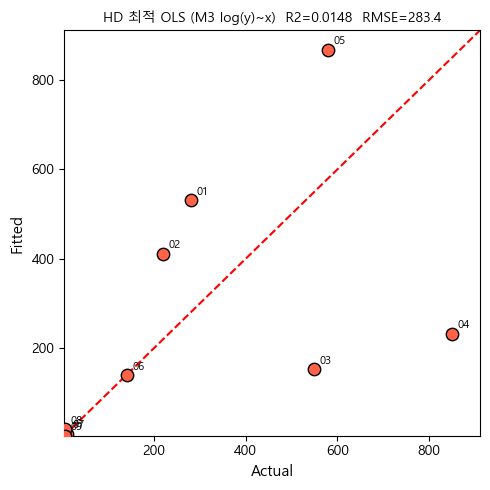

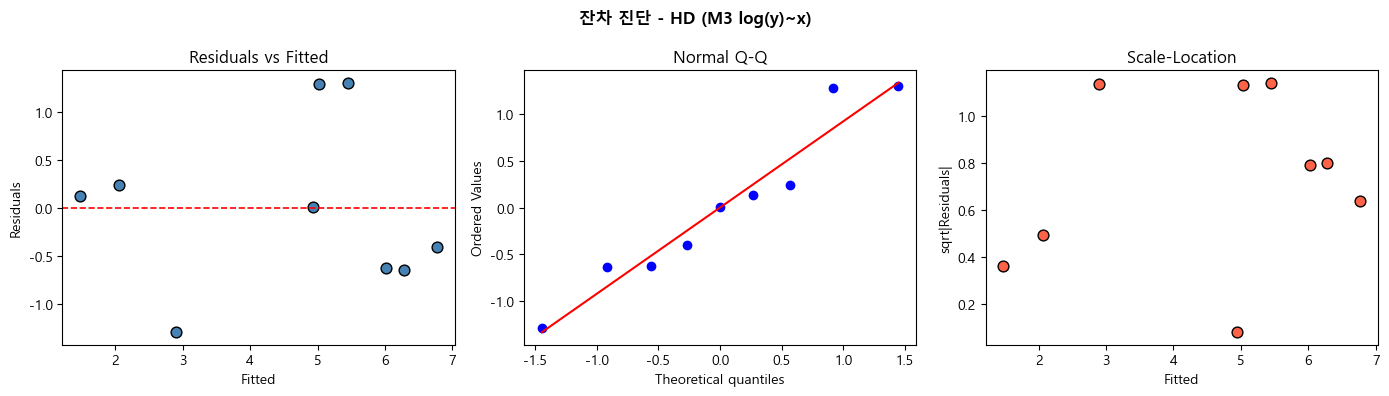

In [10]:
plot_fitted_vs_actual(best_res_HD, best_log_HD, df['y_HD'],
                      'HD 최적 OLS (' + best_label_HD + ')', color='tomato')
plot_residual_diagnostics(best_res_HD, 'HD (' + best_label_HD + ')')

---
## 4. 전체 모형 Fitted vs Actual 비교

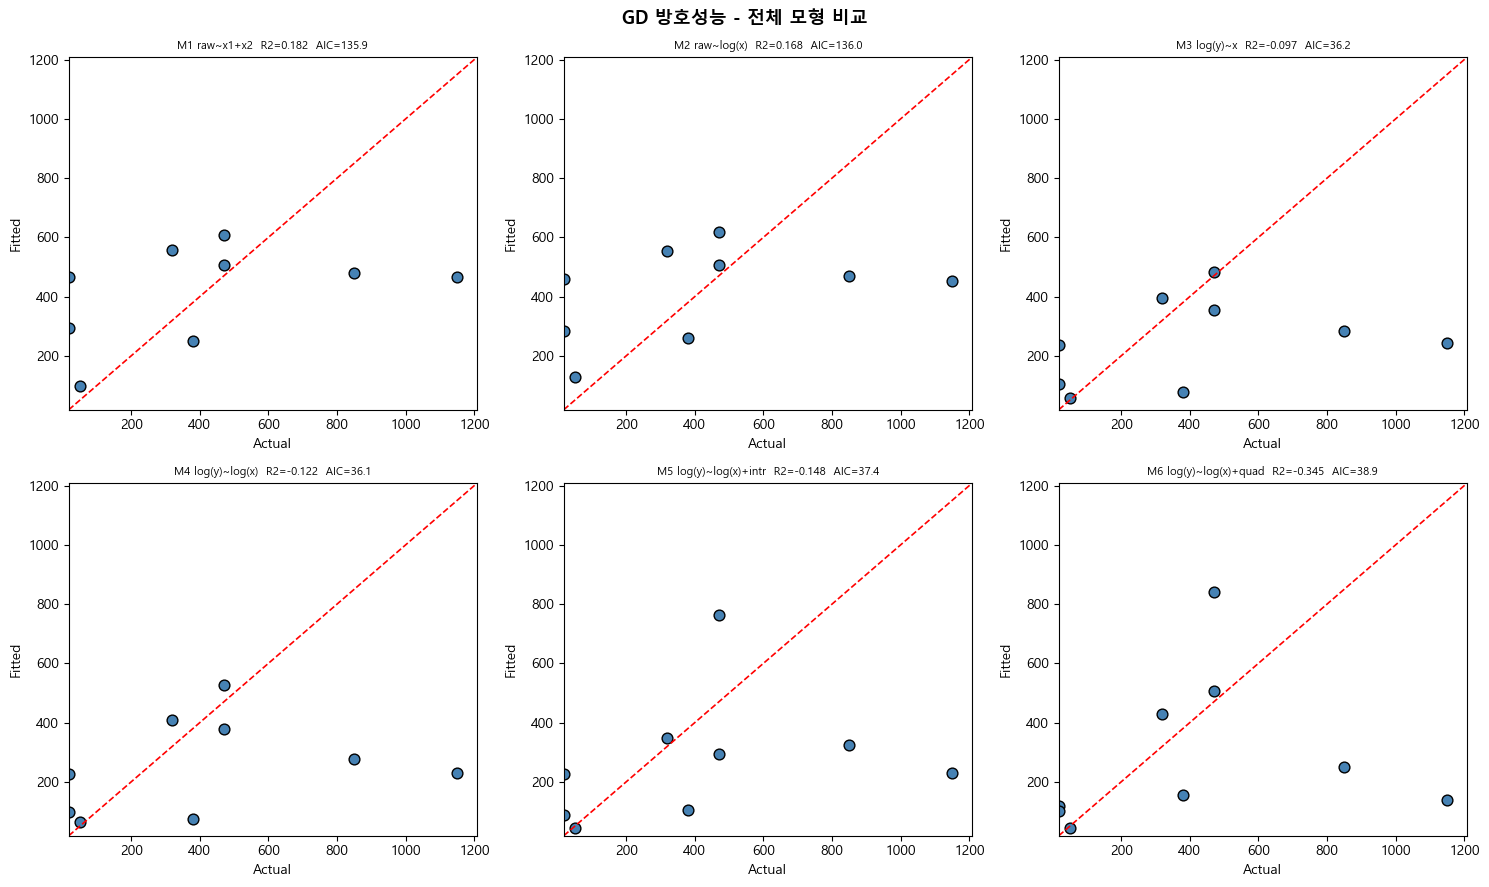

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (label, formula, is_log_y) in zip(axes.flatten(), formulas_GD):
    res   = results_GD[label][0]
    y_fit = np.exp(res.fittedvalues) if is_log_y else res.fittedvalues
    yt    = df['y_GD']
    r2    = r2_score(yt, y_fit)
    rmse  = np.sqrt(mean_squared_error(yt, y_fit))
    ax.scatter(yt, y_fit, color='steelblue', edgecolors='k', s=60)
    lo=min(yt.min(),y_fit.min())*0.9; hi=max(yt.max(),y_fit.max())*1.05
    ax.plot([lo,hi],[lo,hi],'r--',lw=1.2); ax.set_xlim(lo,hi); ax.set_ylim(lo,hi)
    ax.set_xlabel('Actual'); ax.set_ylabel('Fitted')
    ax.set_title(label + '  R2=' + str(round(r2,3)) + '  AIC=' + str(round(res.aic,1)), fontsize=8)
fig.suptitle('GD 방호성능 - 전체 모형 비교', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

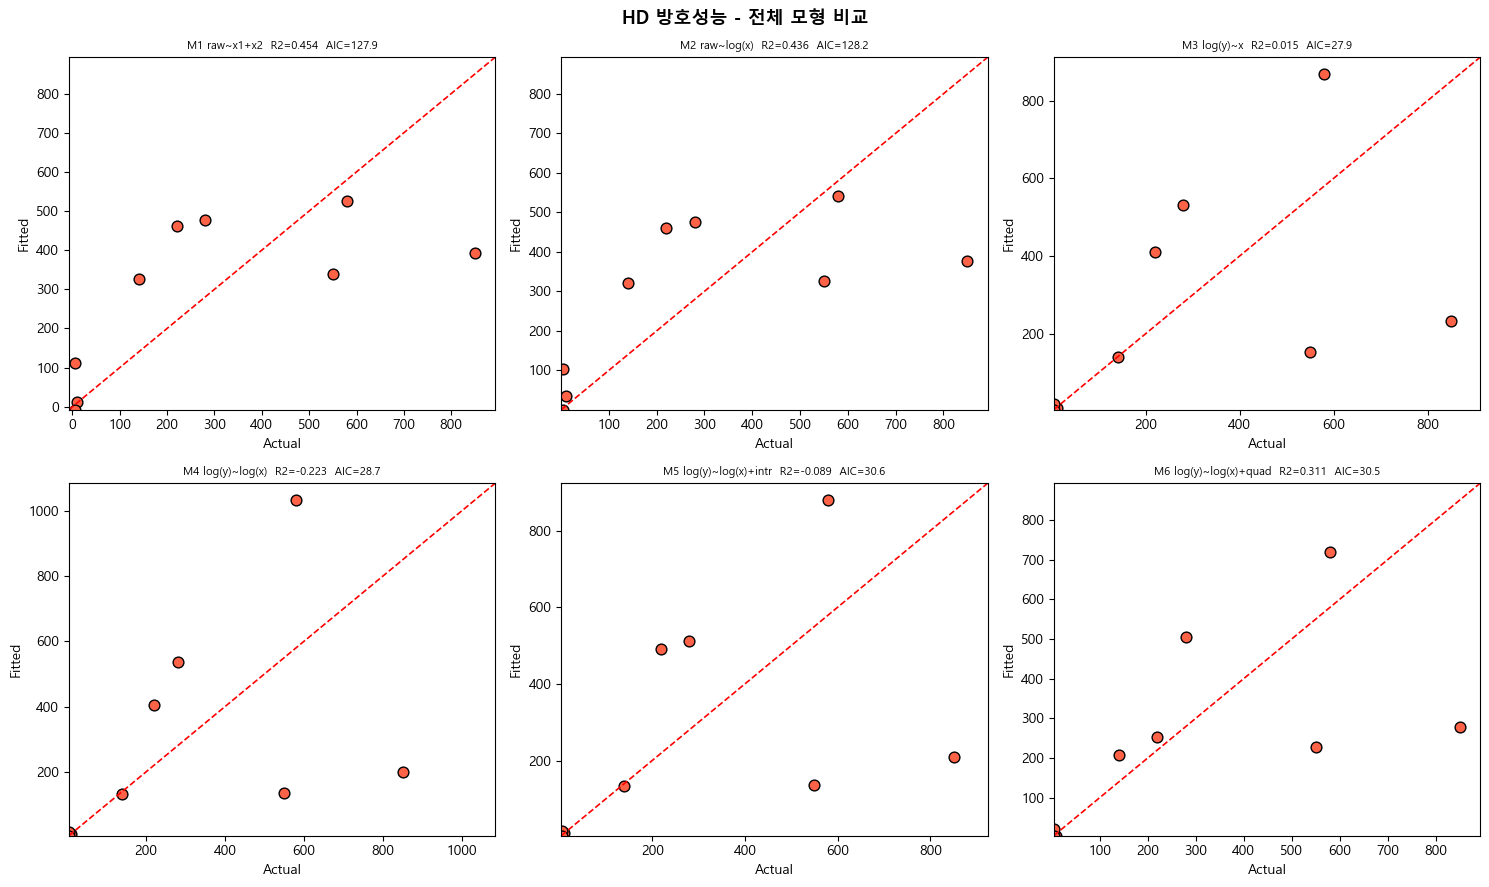

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (label, formula, is_log_y) in zip(axes.flatten(), formulas_HD):
    res   = results_HD[label][0]
    y_fit = np.exp(res.fittedvalues) if is_log_y else res.fittedvalues
    yt    = df['y_HD']
    r2    = r2_score(yt, y_fit)
    rmse  = np.sqrt(mean_squared_error(yt, y_fit))
    ax.scatter(yt, y_fit, color='tomato', edgecolors='k', s=60)
    lo=min(yt.min(),y_fit.min())*0.9; hi=max(yt.max(),y_fit.max())*1.05
    ax.plot([lo,hi],[lo,hi],'r--',lw=1.2); ax.set_xlim(lo,hi); ax.set_ylim(lo,hi)
    ax.set_xlabel('Actual'); ax.set_ylabel('Fitted')
    ax.set_title(label + '  R2=' + str(round(r2,3)) + '  AIC=' + str(round(res.aic,1)), fontsize=8)
fig.suptitle('HD 방호성능 - 전체 모형 비교', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 5. 예측값 비교 테이블

In [13]:
pred_gd = pd.DataFrame({'Sample': df['Sample'], 'Actual_GD': df['y_GD']})
for label, formula, is_log_y in formulas_GD:
    res   = results_GD[label][0]
    y_fit = np.exp(res.fittedvalues) if is_log_y else res.fittedvalues
    pred_gd[label] = y_fit.values.round(1)
print('GD 방호성능 - 모형별 예측값')
display(pred_gd)

GD 방호성능 - 모형별 예측값


,Sample,Actual_GD,M1 raw~x1+x2,M2 raw~log(x),M3 log(y)~x,M4 log(y)~log(x),M5 log(y)~log(x)+intr,M6 log(y)~log(x)+quad
0,ACF25-01,320,557.1,554.9,396.1,407.6,348.7,429.5
1,ACF25-02,470,507.4,506.7,353.3,376.6,763.6,841.6
2,ACF25-03,1150,466.1,454.0,243.8,230.2,228.5,138.3
3,ACF25-04,850,481.1,467.8,284.8,275.8,324.7,250.9
4,ACF25-05,470,606.9,618.0,483.0,525.3,293.0,506.2
5,ACF25-06,20,466.7,459.1,236.2,224.8,225.9,119.7
6,ACF25-07,380,250.9,258.5,77.0,75.5,104.2,154.0
7,ACF25-08,20,295.3,282.2,105.8,96.4,89.5,100.0
8,ACF25-09,50,98.7,128.7,58.2,62.7,43.0,44.9


In [14]:
pred_hd = pd.DataFrame({'Sample': df['Sample'], 'Actual_HD': df['y_HD']})
for label, formula, is_log_y in formulas_HD:
    res   = results_HD[label][0]
    y_fit = np.exp(res.fittedvalues) if is_log_y else res.fittedvalues
    pred_hd[label] = y_fit.values.round(1)
print('HD 방호성능 - 모형별 예측값')
display(pred_hd)

HD 방호성능 - 모형별 예측값


,Sample,Actual_HD,M1 raw~x1+x2,M2 raw~log(x),M3 log(y)~x,M4 log(y)~log(x),M5 log(y)~log(x)+intr,M6 log(y)~log(x)+quad
0,ACF25-01,280,477.6,476.5,530.6,535.7,513.1,505.2
1,ACF25-02,220,461.9,460.2,411.2,403.9,490.6,254.3
2,ACF25-03,550,339.9,327.3,152.5,136.5,136.2,226.8
3,ACF25-04,850,392.4,376.9,231.7,200.4,209.5,279.6
4,ACF25-05,580,526.4,540.3,867.8,1032.5,879.3,718.7
5,ACF25-06,140,326.9,320.0,139.2,132.3,132.5,207.6
6,ACF25-07,10,12.0,36.0,7.9,9.5,10.4,4.9
7,ACF25-08,5,111.2,102.5,18.2,16.2,15.9,20.6
8,ACF25-09,5,-8.3,0.4,4.4,4.7,4.2,4.8


---
## 6. 최적 모형 종합 요약

In [15]:
summary = pd.DataFrame([
    {'target':'GD', 'best_model': best_label_GD,
     'R2': round(best_res_GD.rsquared,4), 'adj_R2': round(best_res_GD.rsquared_adj,4),
     'AIC': round(best_res_GD.aic,2), 'BIC': round(best_res_GD.bic,2),
     'F_pval': round(best_res_GD.f_pvalue,4), 'df_resid': int(best_res_GD.df_resid)},
    {'target':'HD', 'best_model': best_label_HD,
     'R2': round(best_res_HD.rsquared,4), 'adj_R2': round(best_res_HD.rsquared_adj,4),
     'AIC': round(best_res_HD.aic,2), 'BIC': round(best_res_HD.bic,2),
     'F_pval': round(best_res_HD.f_pvalue,4), 'df_resid': int(best_res_HD.df_resid)},
])
print('=== 최적 모형 종합 ===')
display(summary)
print()
print('[해석 가이드]')
print('  adj_R2: 변수 수 페널티 적용 설명력')
print('  AIC/BIC: 낮을수록 좋음 (모형 선택 기준)')
print('  F_pval: 전체 모형 유의성 (n=9, df_resid 소규모 주의)')

=== 최적 모형 종합 ===


,target,best_model,R2,adj_R2,AIC,BIC,F_pval,df_resid
0,GD,M4 log(y)~log(x),0.2430,-0.0093,36.12,36.71,0.4338,6
1,HD,M3 log(y)~x,0.8304,0.7738,27.95,28.54,0.0049,6



[해석 가이드]
  adj_R2: 변수 수 페널티 적용 설명력
  AIC/BIC: 낮을수록 좋음 (모형 선택 기준)
  F_pval: 전체 모형 유의성 (n=9, df_resid 소규모 주의)
